# LangGraph 101

[LLMs](https://python.langchain.com/docs/concepts/chat_models/) make it possible to embed intelligence into a new class of applications. [LangGraph](https://langchain-ai.github.io/langgraph/) is a framework to help build applications with LLMs. Here, we will overview the basics of LangGraph, explain its benefits, show how to use it to build workflows / agents, and show how it works with [LangChain](https://www.langchain.com/) / [LangSmith](https://docs.smith.langchain.com/).

![ecosystem](./img/ecosystem.png)

## Chat models

[Chat models](https://python.langchain.com/docs/concepts/chat_models/) are the foundation of LLM applications. They are typically accessed through a chat interface that takes a list of [messages](https://python.langchain.com/docs/concepts/messages/) as input and returns a [message](https://python.langchain.com/docs/concepts/messages/) as output. LangChain provides [a standardized interface for chat models](https://python.langchain.com/api_reference/langchain/chat_models/langchain.chat_models.base.init_chat_model.html), making it easy to [access many different providers](https://python.langchain.com/docs/integrations/chat/).

In [0]:
!pwd

/Workspace/Users/mai.la@nov.com/agents-from-scratch-ml/notebooks


In [0]:
import mlflow
mlflow.autolog(disable=True)

In [0]:
from dotenv import load_dotenv
load_dotenv("../.env", override=True)

True

In [0]:
# from langchain.chat_models import init_chat_model
# llm = init_chat_model("openai:gpt-4.1", temperature=0)

# Using databricks chat model
from databricks_langchain import ChatDatabricks
llm = ChatDatabricks(
        endpoint="databricks-gpt-5-mini",
        # temperature=0,
        target_uri="databricks",
    )

/home/spark-9f17ad17-65c3-4d6e-8d50-8b/.ipykernel/2407/command-8146038353585309-1085450379:6: DeprecationWarning: The 'target_uri' parameter is deprecated and will be removed in a future version. Use 'workspace_client' parameter instead.
  llm = ChatDatabricks(


## Running the model

The `init_chat_model` interface provides [standardized](https://python.langchain.com/docs/concepts/runnables/) methods for using chat models, which include:
- `invoke()`: A single input is transformed into an output.
- `stream()`: Outputs are [streamed](https://python.langchain.com/docs/concepts/streaming/#stream-and-astream) as they are produced. 

In [0]:
result = llm.invoke("What is an agent?")

Trace(trace_id=tr-9fd4d91bdf70402d76460a9bd91765e4)

In [0]:
result

AIMessage(content='"Agent" has different meanings depending on context. Here are the common ones, with brief explanations and examples so you can pick the sense you need.\n\n1. Philosophy / Action theory\n- An agent is an entity that can act intentionally and make choices. Often implies capacities like beliefs, desires, intentions, and the ability to perform actions that affect the world.\n- Example: A person is a moral/ethical agent responsible for their decisions.\n\n2. Computer science / AI\n- An agent is a system that perceives its environment through sensors and acts on that environment through actuators to achieve goals. Agents can be simple (reflex agents) or complex (learning, planning, multi-agent systems).\n- Example: A web crawler, a robot, or a reinforcement-learning policy.\n\n3. Software agent / Agent-based systems\n- A software program that autonomously performs tasks on behalf of a user or another program, often with some level of intelligence, scheduling, communication

In [0]:
type(result)

langchain_core.messages.ai.AIMessage

In [0]:
from rich.markdown import Markdown
Markdown(result.content)

"Agent" has different meanings depending on context. Here are the common ones, with brief explanations and examples
so you can pick the sense you need.                                                                                

 1 Philosophy / Action theory                                                                                      

 • An agent is an entity that can act intentionally and make choices. Often implies capacities like beliefs,       
   desires, intentions, and the ability to perform actions that affect the world.                                  
 • Example: A person is a moral/ethical agent responsible for their decisions.                                     

 2 Computer science / AI                                                                                           

 • An agent is a system that perceives its environment through sensors and acts on that environment through        
   actuators to achieve goals. Agents can be simple (reflex agents) or complex (learning, planning, multi-agent    
   systems).                                                                                                       
 • Example: A web crawler, a robot, or a reinforcement-learning policy.                                            

 3 Software agent / Agent-based systems                                                                            

 • A software program that autonomously performs tasks on behalf of a user or another program, often with some     
   level of intelligence, scheduling, communication, or negotiation abilities.                                     
 • Example: Email filters, virtual assistants, autonomous trading bots.                                            

 4 Multi-agent systems                                                                                             

 • A collection of interacting agents that coordinate, cooperate, compete, or negotiate to accomplish tasks.       
   Studied in distributed AI and game theory.                                                                      
 • Example: Autonomous vehicles coordinating traffic flow.                                                         

 5 Biology / Medicine                                                                                              

 • An agent refers to a substance or organism that causes an effect, such as a pathogen or a drug.                 
 • Example: A viral agent causes infection; an antimicrobial agent treats bacteria.                                

 6 Law / Business                                                                                                  

 • An agent is a person authorized to act on behalf of another (the principal), with duties and legal              
   responsibilities.                                                                                               
 • Example: A real estate agent acts for a buyer or seller.                                                        

 7 Chemistry / Materials                                                                                           

 • A chemical agent is a compound that causes or facilitates a chemical process.                                   
 • Example: Oxidizing agents, catalysts.                                                                           

If you tell me which field you mean (AI, law, biology, philosophy, etc.), I can give a more detailed definition,   
examples, and relevant properties.

## Tools

[Tools](https://python.langchain.com/docs/concepts/tools/) are utilities that can be called by a chat model. In LangChain, creating tools can be done using the `@tool` decorator, which transforms Python functions into callable tools. It will automatically infer the tool's name, description, and expected arguments from the function definition. You can also use [Model Context Protocol (MCP) servers](https://github.com/langchain-ai/langchain-mcp-adapters) as LangChain-compatible tools. 

In [0]:
from langchain.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

In [0]:
type(write_email)

langchain_core.tools.structured.StructuredTool

In [0]:
write_email.args

{'to': {'title': 'To', 'type': 'string'},
 'subject': {'title': 'Subject', 'type': 'string'},
 'content': {'title': 'Content', 'type': 'string'}}

In [0]:
Markdown(write_email.description)

Write and send an email.

## Tool Calling

Tools can be [called](https://python.langchain.com/docs/concepts/tool_calling/) by LLMs. When a tool is bound to the model, the model can choose to call the tool by returning a structured output with tool arguments. We use the `bind_tools` method to augment an LLM with tools.

![tool-img](img/tool_call_detail.png)

Providers often have [parameters such as `tool_choice`](https://python.langchain.com/docs/how_to/tool_choice/) to enforce calling specific tools. `any` will select at least one of the tools.

In addition, we can [set `parallel_tool_calls=False`](https://python.langchain.com/docs/how_to/tool_calling_parallel/) to ensure the model will only call one tool at a time.

In [0]:
# Connect tools to a chat model
model_with_tools = llm.bind_tools([write_email], tool_choice="any", parallel_tool_calls=False)

# The model will now be able to call tools
output = model_with_tools.invoke("Draft a response to my boss (boss@company.ai) about tomorrow's meeting")

Trace(trace_id=tr-008c95d9166e185b85d3c76ed325e571)

In [0]:
type(output)

langchain_core.messages.ai.AIMessage

In [0]:
output

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_WBQs3t21JnJILhfQA5CqQy1C', 'function': {'arguments': '{"to":"boss@company.ai","subject":"Tomorrow\'s Meeting","content":"Hi [Boss\'s Name],\\n\\nI wanted to confirm our meeting scheduled for tomorrow. Please let me know if the time is still 10:00 AM and if there\'s anything specific you would like me to prepare or bring. I can provide a brief update on the [project name] progress, highlights, and blockers, or prepare slides if you prefer.\\n\\nIf you\'d like to reschedule or change the agenda, I\'m flexible and can adjust.\\n\\nThanks,\\n[Your Name]"}', 'name': 'write_email'}, 'type': 'function'}]}, response_metadata={'usage': {'prompt_tokens': 148, 'completion_tokens': 136, 'total_tokens': 284}, 'prompt_tokens': 148, 'completion_tokens': 136, 'total_tokens': 284, 'model': 'gpt-5-mini-2025-08-07', 'model_name': 'gpt-5-mini-2025-08-07', 'finish_reason': 'tool_calls'}, id='lc_run--eb5f6fc2-5d08-4718-95f8-582830a8a91e-0'

In [0]:
# Extract tool calls and execute them
args = output.tool_calls[0]['args']
args

{'to': 'boss@company.ai',
 'subject': "Tomorrow's Meeting",
 'content': "Hi [Boss's Name],\n\nI wanted to confirm our meeting scheduled for tomorrow. Please let me know if the time is still 10:00 AM and if there's anything specific you would like me to prepare or bring. I can provide a brief update on the [project name] progress, highlights, and blockers, or prepare slides if you prefer.\n\nIf you'd like to reschedule or change the agenda, I'm flexible and can adjust.\n\nThanks,\n[Your Name]"}

In [0]:
# Call the tool
result = write_email.invoke(args)
Markdown(result)

Email sent to boss@company.ai with subject 'Tomorrow's Meeting' and content: Hi [Boss's Name],                     

I wanted to confirm our meeting scheduled for tomorrow. Please let me know if the time is still 10:00 AM and if    
there's anything specific you would like me to prepare or bring. I can provide a brief update on the [project name]
progress, highlights, and blockers, or prepare slides if you prefer.                                               

If you'd like to reschedule or change the agenda, I'm flexible and can adjust.                                     

Thanks, [Your Name]

Trace(trace_id=tr-9171c7194764c7d9e75c1cc9f3c659eb)

![basic_prompt](img/tool_call.png)

## Workflows
 
There are many patterns for building applications with LLMs. 

[We can embed LLM calls into pre-defined workflows](https://langchain-ai.github.io/langgraph/tutorials/workflows/), giving the system more agency to make decisions. 

As an example, we could add a router step to determine whether to write an email or not.

![workflow_example](img/workflow_example.png)

## Agents

We can further increase agency, allowing the LLM to dynamically direct its own tool usage. 

[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) are typically implemented as tool calling in a loop, where the output of each tool call is used to inform the next action.

![agent_example](img/agent_example.png)

Agents are well suited to open-ended problems where it's difficult to predict the *exact* steps needed in advance.
 
Workflows are often appropriate when the control flow can easily be defined in advance. 

![workflow_v_agent](img/workflow_v_agent.png)

## What is LangGraph? 

[LangGraph](https://langchain-ai.github.io/langgraph/concepts/high_level/) provides low-level supporting infrastructure that sits underneath *any* workflow or agent. 

It does not abstract prompts or architecture, and provides a few benefits:

- **Control**: Make it easy to define and / or combine agents and workflows.
- **Persistence**: Provide a way to persist the state of a graph, which enables both memory and human-in-the-loop.
- **Testing, Debugging, and Deployment**: Provide an easy onramp for testing, debugging, and deploying applications.

### Control

LangGraph lets you define your application as a graph with:

1. *State*: What information do we need to track over the course of the application?
2. *Nodes*: How do we want to update this information over the course of the application?
3. *Edges*: How do we want to connect these nodes together?

We can use the [`StateGraph` class](https://langchain-ai.github.io/langgraph/concepts/low_level/#graphs) to initialize a LangGraph graph with a [`State` object](https://langchain-ai.github.io/langgraph/concepts/low_level/#state).

`State` defines the schema for information we want to track over the course of the application. 

This can be any object with `getattr()` in python, such as a dictionary, dataclass, or Pydantic object: 

- TypeDict is fastest but doesn’t support defaults
- Dataclass is basically as fast, supports dot syntax `state.foo`, and has defaults. 
- Pydantic is slower (especially with custom validators) but gives type validation.

In [0]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class StateSchema(TypedDict):
    request: str
    email: str

workflow = StateGraph(StateSchema)

Each node is simply a python function or typescript code. This gives us full control over the logic inside each node.

They receive the current state, and return a dictionary to update the state.

By default, [state keys are overwritten](https://langchain-ai.github.io/langgraph/how-tos/state-reducers/). 

However, you can [define custom update logic](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers). 

![nodes_edges](img/nodes_edges.png)

In [0]:
def write_email_node(state: StateSchema) -> StateSchema:
    # Imperative code that processes the request
    output = model_with_tools.invoke(state["request"])
    args = output.tool_calls[0]['args']
    email = write_email.invoke(args)
    return {"email": email}

Edges connect nodes together. 

We specify the control flow by adding edges and nodes to our state graph. 

In [0]:
workflow = StateGraph(StateSchema)
workflow.add_node("write_email_node", write_email_node)
workflow.add_edge(START, "write_email_node")
workflow.add_edge("write_email_node", END)

app = workflow.compile()

In [0]:
app.invoke({"request": "Draft a response to my boss (boss@company.ai) about tomorrow's meeting"})

{'request': "Draft a response to my boss (boss@company.ai) about tomorrow's meeting",
 'email': "Email sent to boss@company.ai with subject 'Tomorrow's Meeting' and content: Hi [Boss Name],\n\nI’m confirming that I’ll attend tomorrow’s meeting at the scheduled time. I’ve reviewed the agenda and will come prepared with the status updates on Project X, the blockers we’re facing (see notes below), and proposed solutions. If you’d like me to present any specific slide or deep-dive into a particular topic, please let me know.\n\nCurrent blockers and topics I plan to cover:\n- Integration delays with Vendor Y — ETA and mitigation plan.\n- Resource constraint on backend work — request for additional support.\n- QA timeline impact — test coverage and risk areas.\n\nIf the meeting time or agenda changes, please tell me; otherwise I’ll be ready.\n\nBest regards,\n[Your Name]"}

Trace(trace_id=tr-eff75e16a2c0a2338757e47df97a98c8)

Routing between nodes can be done [conditionally](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges) using a simple function. 

The return value of this function is used as the name of the node (or list of nodes) to send the state to next. 

You can optionally provide a dictionary that maps the `should_continue` output to the name of the next node.

In [0]:
from typing import Literal
from langgraph.graph import MessagesState
from email_assistant.utils import show_graph

def call_llm(state: MessagesState) -> MessagesState:
    """Run LLM"""

    output = model_with_tools.invoke(state["messages"])
    return {"messages": [output]}

def run_tool(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        observation = write_email.invoke(tool_call["args"])
        result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
    return {"messages": result}

def should_continue(state: MessagesState) -> Literal["run_tool", "__end__"]:
    """Route to tool handler, or end if Done tool called"""
    
    # Get the last message
    messages = state["messages"]
    last_message = messages[-1]
    
    # If the last message is a tool call, check if it's a Done tool call
    if last_message.tool_calls:
        return "run_tool"
    # Otherwise, we stop (reply to the user)
    return END

workflow = StateGraph(MessagesState)
workflow.add_node("call_llm", call_llm)
workflow.add_node("run_tool", run_tool)
workflow.add_edge(START, "call_llm")
workflow.add_conditional_edges("call_llm", should_continue, {"run_tool": "run_tool", END: END})
workflow.add_edge("run_tool", END)

# Run the workflow
app = workflow.compile()

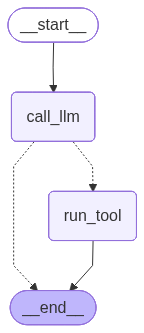

In [0]:
from IPython.display import Image, display

# Display the graph structure
display(Image(app.get_graph().draw_mermaid_png()))

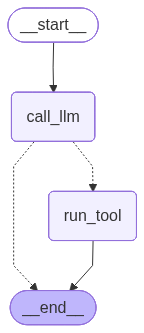

In [0]:
show_graph(app)

In [0]:
result = app.invoke({"messages": [{"role": "user", "content": "Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!"}]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!
================================== Ai Message ==================================
Tool Calls:
  write_email (call_gQE1q4c2xnJJu0EOYMDux6mB)
 Call ID: call_gQE1q4c2xnJJu0EOYMDux6mB
  Args:
    to: boss@company.ai
    subject: Confirmation: Attending Interrupt!
    content: Hi [Boss Name],

I’m writing to confirm that I would like to attend Interrupt!. I appreciate the opportunity and will make the necessary arrangements to participate. Please let me know if there are any approvals, travel plans, or further steps you’d like me to take.

Thanks,
[Your Name]
================================= Tool Message =================================

Email sent to boss@company.ai with subject 'Confirmation: Attending Interrupt!' and content: Hi [Boss Name],

I’m writing to confirm that I would like to attend Interrupt!. I appreciate 

Trace(trace_id=tr-e88d70a8a176e75820648e2020e9b377)

With these low level components, you can build many many different workflows and agents. See [this tutorial](https://langchain-ai.github.io/langgraph/tutorials/workflows/)!

Because agents are such a common pattern, [LangGraph](https://langchain-ai.github.io/langgraph/tutorials/workflows/#pre-built) has [a pre-built agent](https://langchain-ai.github.io/langgraph/agents/overview/?ref=blog.langchain.dev#what-is-an-agent) abstraction.

With LangGraph's [pre-built method](https://langchain-ai.github.io/langgraph/tutorials/workflows/#pre-built), we just pass in the LLM, tools, and prompt. 

In [0]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model=llm,
    tools=[write_email],
    prompt="Respond to the user's request using the tools provided."  
)

# Run the agent
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!"}]}
)

for m in result["messages"]:
    m.pretty_print()

/home/spark-9f17ad17-65c3-4d6e-8d50-8b/.ipykernel/2407/command-8146038353585337-2575284484:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


================================ Human Message =================================

Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!
================================== Ai Message ==================================
Tool Calls:
  write_email (call_DDoIJnQHlATejAxJ3hVJnVL8)
 Call ID: call_DDoIJnQHlATejAxJ3hVJnVL8
  Args:
    to: boss@company.ai
    subject: Attendance Confirmation for Interrupt!
    content: Hi [Boss Name],

I’m writing to confirm that I would like to attend Interrupt!. Please let me know if there are any next steps I should take (registration details, travel arrangements, or approvals needed).

Thanks,
[Your Name]
================================= Tool Message =================================
Name: write_email

Email sent to boss@company.ai with subject 'Attendance Confirmation for Interrupt!' and content: Hi [Boss Name],

I’m writing to confirm that I would like to attend Interrupt!. Please let me know if there are any next steps 

Trace(trace_id=tr-229fedc905426ff7571a8724c559b166)

### Persistence

#### Threads

It can be very useful to allow agents to pause during long running tasks.

LangGraph has a built-in persistence layer, implemented through checkpointers, to enable this. 

When you compile graph with a checkpointer, the checkpointer saves a [checkpoint](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpoints) of the graph state at every step. 

Checkpoints are saved to a thread, which can be accessed after graph execution completes.

![checkpointer](img/checkpoints.png)

We compile the graph with a [checkpointer](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries).


In [0]:
from langgraph.checkpoint.memory import InMemorySaver

agent = create_react_agent(
    model=llm,
    tools=[write_email],
    prompt="Respond to the user's request using the tools provided.",
    checkpointer=InMemorySaver()
)

config = {"configurable": {"thread_id": "1"}}
result = agent.invoke({"messages": [{"role": "user", "content": "What are some good practices for writing emails?"}]}, config)
                    

/home/spark-9f17ad17-65c3-4d6e-8d50-8b/.ipykernel/2407/command-8146038353585339-1218495830:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


Trace(trace_id=tr-312e4f69e1dafecaf9c0e4e2f5fabad4)

In [0]:
# Get the latest state snapshot
config = {"configurable": {"thread_id": "1"}}
state = agent.get_state(config)
for message in state.values['messages']:
    message.pretty_print()

================================ Human Message =================================

What are some good practices for writing emails?
================================== Ai Message ==================================

Good email writing is about clarity, tone, and respect for the reader’s time. Here are practical, widely applicable practices you can use for professional and personal emails.

1. Use a clear subject line
- Make it specific and action-oriented when possible (e.g., “Quarterly budget numbers — please review by Fri 5/2”).
- Avoid vague subjects like “Hey” or “Question.”

2. Start with an appropriate greeting
- Use a friendly but suitable salutation for the relationship: “Hi [Name],” “Hello [Name],” or “Dear [Name]” for formal contexts.
- Use a name rather than “To whom it may concern” when possible.

3. State the purpose up front
- In the first one or two sentences, say why you’re writing. Readers should not have to hunt for the main point.
- Example: “I’m writing to request appr

In [0]:
# Continue the conversation
result = agent.invoke({"messages": [{"role": "user", "content": "Good, let's use lesson 3 to craft a response to my boss confirming that I want to attend Interrupt"}]}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

What are some good practices for writing emails?
================================== Ai Message ==================================

Good email writing is about clarity, tone, and respect for the reader’s time. Here are practical, widely applicable practices you can use for professional and personal emails.

1. Use a clear subject line
- Make it specific and action-oriented when possible (e.g., “Quarterly budget numbers — please review by Fri 5/2”).
- Avoid vague subjects like “Hey” or “Question.”

2. Start with an appropriate greeting
- Use a friendly but suitable salutation for the relationship: “Hi [Name],” “Hello [Name],” or “Dear [Name]” for formal contexts.
- Use a name rather than “To whom it may concern” when possible.

3. State the purpose up front
- In the first one or two sentences, say why you’re writing. Readers should not have to hunt for the main point.
- Example: “I’m writing to request appr

Trace(trace_id=tr-7efab53cad4a48a3126650343219180b)

In [0]:
# Continue the conversation
result = agent.invoke({"messages": [{"role": "user", "content": "I like this, let's write the email to boss@company.ai"}]}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

What are some good practices for writing emails?
================================== Ai Message ==================================

Good email writing is about clarity, tone, and respect for the reader’s time. Here are practical, widely applicable practices you can use for professional and personal emails.

1. Use a clear subject line
- Make it specific and action-oriented when possible (e.g., “Quarterly budget numbers — please review by Fri 5/2”).
- Avoid vague subjects like “Hey” or “Question.”

2. Start with an appropriate greeting
- Use a friendly but suitable salutation for the relationship: “Hi [Name],” “Hello [Name],” or “Dear [Name]” for formal contexts.
- Use a name rather than “To whom it may concern” when possible.

3. State the purpose up front
- In the first one or two sentences, say why you’re writing. Readers should not have to hunt for the main point.
- Example: “I’m writing to request appr

Trace(trace_id=tr-02761c654f2dd206f2e586ef84bbb4bf)

#### Interrupts

In LangGraph, we can also use [interrupts](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/wait-user-input/) to stop graph execution at specific points.

Often this is used to collect input from a user and continue execution with collected input.

In [0]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    input: str
    user_feedback: str

def step_1(state):
    print("---Step 1---")
    pass

def human_feedback(state):
    print("---human_feedback---")
    feedback = interrupt("Please provide feedback:")
    return {"user_feedback": feedback}

def step_3(state):
    print("---Step 3---")
    pass

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = InMemorySaver()

# Add
graph = builder.compile(checkpointer=memory)

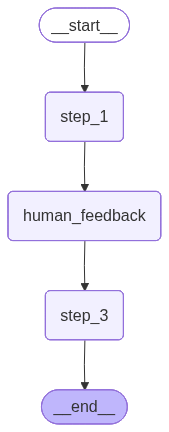

In [0]:
show_graph(graph)

In [0]:
# Input
initial_input = {"input": "hello world"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

---Step 1---
{'step_1': None}


---human_feedback---
{'__interrupt__': (Interrupt(value='Please provide feedback:', id='b4e32cc1e690db2b2b210c3fdcf19e5c'),)}




Trace(trace_id=tr-2945f5e278549a3bf2be95b30f441b7f)

To resume from an interrupt, we can use [the `Command` object](https://langchain-ai.github.io/langgraph/how-tos/command/). 

We'll use it to resume the graph from the interrupted state, passing the value to return from the interrupt call to `resume`. 

In [0]:
# Continue the graph execution
for event in graph.stream(
    Command(resume="go to step 3!"),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

---human_feedback---
{'human_feedback': {'user_feedback': 'go to step 3!'}}


---Step 3---
{'step_3': None}




Trace(trace_id=tr-b3cdc02e4b5fd0f255565665f169f208)

### Tracing

When we are using LangChain or LangGraph, LangSmith logging [will work out of the box](https://docs.smith.langchain.com/observability/how_to_guides/trace_with_langgraph) with the following environment variables set:

```
export LANGSMITH_TRACING=true
export LANGSMITH_API_KEY="<your-langsmith-api-key>"
```

Here is the LangSmith trace from above agent execution:

https://smith.langchain.com/public/6f77014f-d054-44ed-aa2c-8b06ceab689f/r

We can see that the agent is able to continue the conversation from the previous state because we used a checkpointer.

### Deployment

We can also deploy our graph using [LangGraph Platform](https://langchain-ai.github.io/langgraph/concepts/langgraph_platform/). 

This creates a server [with an API](https://langchain-ai.github.io/langgraph/cloud/reference/api/api_ref.html) that we can use to interact with our graph and an interactive IDE, LangGraph [Studio](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/).

We simply need to ensure our project has [a structure](https://langchain-ai.github.io/langgraph/concepts/application_structure/) like this:

```
my-app/
├── src/email_assistant # all project code lies within here
│   └── langgraph101.py # code for constructing your graph
├── .env # environment variables
├── langgraph.json  # configuration file for LangGraph
└── pyproject.toml # dependencies for your project
```

The `langgraph.json` file specifies the dependencies, graphs, environment variables, and other settings required to start a LangGraph server.

To test this, let's deploy `langgraph_101.py`. We have it in our `langgraph.json` file in this repo:

```
 "langgraph101": "./src/email_assistant/langgraph_101.py:app",
```

For LangGraph Platform, there are a range of [deployment options](https://langchain-ai.github.io/langgraph/tutorials/deployment/): 
 
* Local deployments can be started with `langgraph dev` from the root directory of the repo. Checkpoints are saved to the local filesystem.
* There are also various [self-hosted options](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options). 
* For hosted deployments, checkpoints are saved to Postgres using a postgres [checkpointer](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries). 

Test: 
```
Draft a response to my boss (boss@company.ai) confirming that I want to attent Interrupt!
```

Here we can see a visualization of the graph as well as the graph state in Studio.

![langgraph_studio](img/langgraph_studio.png)

Also, you can see API docs for the local deployment here:

http://127.0.0.1:2024/docs